# Handwriting Verification with BCE Loss

This notebook trains multiple Siamese networks for handwriting verification using Binary Cross-Entropy loss.

## Setup

In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import project modules
from src.utils import set_seed, get_device, print_model_info
from src.data import create_dataloaders
from src.models import get_model, list_models
from src.training import train_multiple_models
from src.evaluation import create_training_report

# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()

print("✓ Setup complete")

Using device: cpu
✓ Setup complete


## Configuration

In [2]:
# Data configuration
DATA_ROOT = "../datasets/processed-handwritten/iam_processed"  # Adjust path as needed
TARGET_SIZE = 448
BATCH_SIZE = 16
NUM_WORKERS = 4
PAIRS_PER_WRITER = 100

# Training configuration
EPOCHS = 1
PATIENCE = 5
RESULTS_DIR = "../results"

# Models to train
MODELS_TO_TRAIN = [
    'efficientnet_b0',
    'efficientnet_b1',
    'efficientnet_v2',
    'regnet_y_400mf',
]

print(f"Data root: {DATA_ROOT}")
print(f"Target size: {TARGET_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Models to train: {MODELS_TO_TRAIN}")

Data root: ../datasets/processed-handwritten/iam_processed
Target size: 448
Batch size: 16
Epochs: 1
Models to train: ['efficientnet_b0', 'efficientnet_b1', 'efficientnet_v2', 'regnet_y_400mf']


## Load Data

In [3]:
# Create dataloaders
train_loader, test_loader, train_dirs, test_dirs = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    test_size=0.2,
    pairs_per_writer=PAIRS_PER_WRITER,
    target_size=TARGET_SIZE,
    random_state=42
)

print(f"\nTrain writers: {len(train_dirs)} | Test writers: {len(test_dirs)}")
print(f"Train pairs: {len(train_loader.dataset)} | Test pairs: {len(test_loader.dataset)}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train writers: 525 | Test writers: 132
Train pairs: 24500 | Test pairs: 5600
Train batches: 1532 | Test batches: 350


## Visualize Sample Pairs

/home/lorenzo/Documenti/GitHub/HandVerify/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


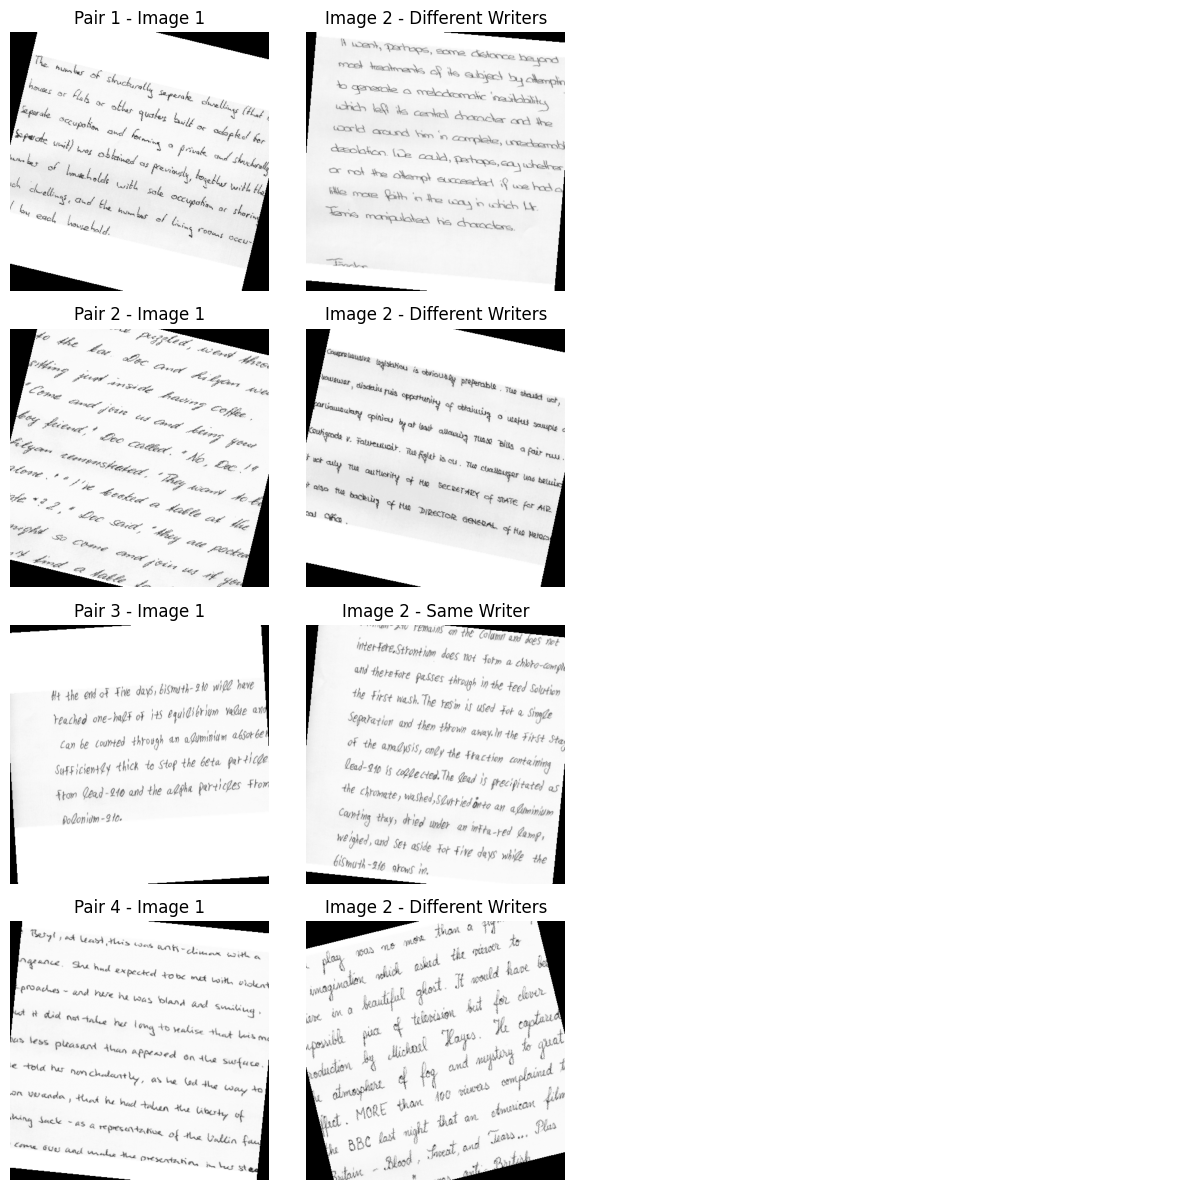

In [4]:
# Get a batch of samples
img1, img2, labels = next(iter(train_loader))

# Plot some pairs
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(4):
    # First image
    axes[i, 0].imshow(img1[i].squeeze(), cmap='gray')
    axes[i, 0].set_title(f"Pair {i+1} - Image 1")
    axes[i, 0].axis('off')
    
    # Second image
    axes[i, 1].imshow(img2[i].squeeze(), cmap='gray')
    label_text = "Same Writer" if labels[i] == 1 else "Different Writers"
    axes[i, 1].set_title(f"Image 2 - {label_text}")
    axes[i, 1].axis('off')
    
    # Empty columns
    axes[i, 2].axis('off')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

## Model Information

In [5]:
print("Available models:")
for model_name in list_models():
    print(f"  - {model_name}")

print(f"\nModels selected for training: {MODELS_TO_TRAIN}")

# Print info for each selected model
for model_name in MODELS_TO_TRAIN:
    model = get_model(model_name)
    print_model_info(model, model_name)
    del model

Available models:
  - resnet18
  - resnet34
  - resnet50
  - efficientnet_b0
  - efficientnet_b1
  - efficientnet_v2
  - mobilenet_v3_small
  - mobilenet_v3_large
  - densenet121
  - regnet_y_400mf

Models selected for training: ['efficientnet_b0', 'efficientnet_b1', 'efficientnet_v2', 'regnet_y_400mf']

Model: efficientnet_b0
Parameters: 5.48M (5,484,349)


Model: efficientnet_b1
Parameters: 7.99M (7,989,985)


Model: efficientnet_v2
Parameters: 21.65M (21,654,433)


Model: regnet_y_400mf
Parameters: 4.52M (4,519,785)



## Training

Train all selected models sequentially.

In [6]:
# Create models dictionary
models_dict = {name: lambda n=name: get_model(n) for name in MODELS_TO_TRAIN[:1]}

# Train all models
results = train_multiple_models(
    models_dict=models_dict,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
    results_dir=RESULTS_DIR
)

print("\n✓ All models trained successfully!")


Starting training: efficientnet_b0


Training efficientnet_b0



KeyboardInterrupt: 

## Results Analysis

In [ ]:
# Print summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)

for model_name, result in results.items():
    best_loss = result['best_loss']
    final_acc = result['history']['test_acc'][-1]
    print(f"{model_name:20s}: Loss={best_loss:.4f} | Final Acc={final_acc:.4f}")

# Find best model
best_model = min(results.items(), key=lambda x: x[1]['best_loss'])
print(f"\n✓ Best model: {best_model[0]} (loss: {best_model[1]['best_loss']:.4f})")

## Visualizations

In [ ]:
from src.evaluation import (
    plot_training_history,
    plot_multiple_models_comparison,
    plot_results_summary
)

# Plot individual model histories
for model_name, result in results.items():
    plot_training_history(result['history'], model_name)

In [ ]:
# Compare test loss across models
plot_multiple_models_comparison(results, metric='test_loss')

In [ ]:
# Compare test accuracy across models
plot_multiple_models_comparison(results, metric='test_acc')

In [ ]:
# Results summary
plot_results_summary(results)

## Generate Full Report

In [ ]:
# Create comprehensive report with all visualizations
create_training_report(results, save_dir=RESULTS_DIR)

print(f"\n✓ Complete training report saved to {RESULTS_DIR}")

## Model Evaluation

Detailed evaluation of the best model.

In [ ]:
from src.evaluation import evaluate_model_comprehensive, plot_confusion_matrix
from src.utils import load_checkpoint

# Load best model
best_model_name = best_model[0]
model = get_model(best_model_name)
checkpoint_path = os.path.join(RESULTS_DIR, f"{best_model_name}_best.pth")
model = load_checkpoint(model, checkpoint_path, device)
model.eval()

# Collect predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for img1, img2, labels in test_loader:
        img1, img2 = img1.to(device), img2.to(device)
        outputs = model(img1, img2).squeeze()
        all_preds.extend(outputs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute comprehensive metrics
metrics = evaluate_model_comprehensive(all_preds, all_labels)

print(f"\n{'='*60}")
print(f"EVALUATION METRICS - {best_model_name}")
print(f"{'='*60}")
for metric, value in metrics.items():
    if isinstance(value, float):
        print(f"{metric:20s}: {value:.4f}")
    else:
        print(f"{metric:20s}: {value}")

In [ ]:
# Plot confusion matrix
from src.evaluation import compute_confusion_matrix

cm = compute_confusion_matrix(all_preds, all_labels)
plot_confusion_matrix(cm, best_model_name)

## Save Results Summary

In [ ]:
import pandas as pd

# Create summary DataFrame
summary_data = []
for model_name, result in results.items():
    history = result['history']
    summary_data.append({
        'model': model_name,
        'best_test_loss': result['best_loss'],
        'final_test_acc': history['test_acc'][-1],
        'final_train_acc': history['train_acc'][-1],
        'epochs_trained': len(history['epoch'])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('best_test_loss')

# Save to CSV
summary_path = os.path.join(RESULTS_DIR, 'training_summary.csv')
summary_df.to_csv(summary_path, index=False)

print("\nTraining Summary:")
print(summary_df.to_string(index=False))
print(f"\n✓ Summary saved to {summary_path}")